## Overall Structure

In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [333]:
# Load the dataset
df = pd.read_excel('C:\\Users\\Travail\\OneDrive\\Desktop\\FUFA\\League Matches\\UPL\\all_league_matches_cleaned.xlsx')

In [334]:
# strip whitespace, replace spaces/slashes with underscores
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'\s+', '_', regex=True)
      .str.replace(r'[\/\(\)\-]', '', regex=True)
)


In [335]:
df = df.rename(columns={'home_team': 'player_club', 'away_team': 'against_club'})

In [336]:
cat_cols = ['split_name','general_position', 'player_club', 'against_club', 'result','match_day','location','player_name']#categorical columns
unique_cols = ['date','player_name','split_name','match_day','player_club','against_club']#identifier columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['durationmin','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio']# interested numeric columns

## Data Cleaning and Type Conversion

In [337]:

def clean_text(s):
    if pd.isnull(s):
        return s
    s = s.strip()                        # Remove leading/trailing whitespace
    s = re.sub(r'\s+', ' ', s)          # Replace multiple spaces with single
    s = s.lower()                       # Convert to lowercase (optional)
    s = s.replace('_', ' ')             # Replace underscores with space
    s = s.title()                       # Convert to Title Case
    return s

# Apply cleaning to each text column
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)


In [338]:
#Identify the columns with missing data
missing_counts = df.isnull().sum().sort_values(ascending=False)
len(missing_counts[missing_counts > 0])


0

In [339]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

for c in cat_cols:
    df[c] = df[c].astype('category')


In [340]:
df = df.drop_duplicates(subset=unique_cols, keep='first')

## High Level Summary Stats

### Numeric Summary

In [341]:
def describe_numeric_columns(df):
    n_desc = df[numeric_cols].describe().T
    n_desc = n_desc.drop(['25%', '75%'], axis=1)
    n_desc = n_desc.rename(columns={'50%': 'median'})
    display(n_desc.T[num_cols].T)

describe_numeric_columns(df)

,count,mean,std,min,median,max
durationmin,12190.0,46.899262,10.589997,1.0,48.00000,102.0000
distance_km,12190.0,3.399203,2.143596,0.0,4.22435,12.4487
sprint_distance_m,12190.0,326.711757,276.196342,0.0,318.26450,2125.1480
power_plays,12190.0,23.304020,18.311054,0.0,25.00000,121.0000
energy_kcal,12190.0,414.524475,264.823111,0.0,511.59860,1545.6276
impacts,12190.0,2.767104,3.203824,0.0,2.00000,40.0000
player_load,12190.0,160.228705,92.253054,0.0,190.07695,558.6705
top_speed_kmh,12190.0,23.608662,9.191281,0.0,27.32820,36.4163
distance_per_min_mmin,12190.0,72.414570,42.119418,0.0,90.52235,152.0751
power_score_wkg,12190.0,5.751707,3.422401,0.0,7.12705,12.6818


### Categoric Summary

In [342]:
def describe_categorical_columns(df):
    cat_vars = df.select_dtypes(include='category').columns
    c_desc = df[cat_vars].describe().T
    c_desc['%age'] = c_desc['freq'] / len(df) * 100
    display(c_desc)

describe_categorical_columns(df)

,count,unique,top,freq,%age
split_name,12190,4,2Nd.Half,5961,48.900738
match_day,12190,30,8,519,4.257588
player_club,12190,16,Wakiso Giants Fc,1222,10.02461
against_club,12190,16,Vipers Sc,871,7.145201
location,12190,2,Away,6129,50.278917
result,12190,3,Win,4549,37.317473
player_name,12190,444,Timothy Oyamo,71,0.582445
general_position,12190,5,Defender,4065,33.347006


### Distribution Checks

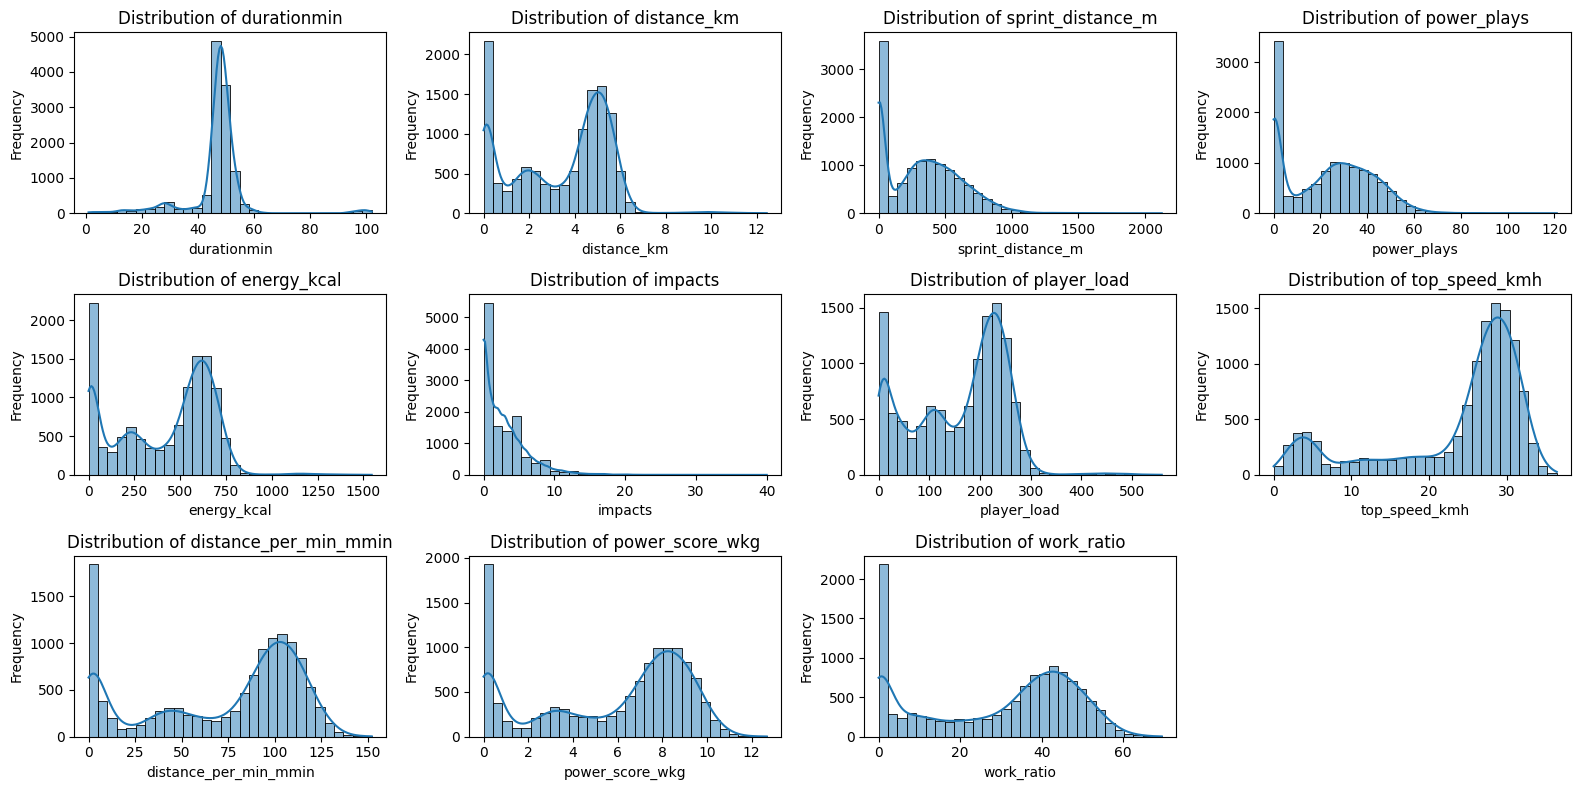

In [343]:
def plot_numerical_distributions(df):
    plt.figure(figsize=(16, 8))
    for i, col in enumerate(num_cols):
        plt.subplot(3, 4, i + 1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()

plot_numerical_distributions(df)


## Basic Filtering

In [344]:
df =df[df['split_name'] != 'Warm Up'] #Remove warm up data from the dataset
df = df[df['split_name'] != 'Game'] #Remove aggregated game data from the dataset(because we only considered 1st and 2nd half splits for analysis)
df=df.drop('player_position', axis=1) #Drop player position column because it has too many unique values and is not useful for analysis
df = df[df['player_name'] != 'Solomon Jjumba'] # Remove player with no general position,Solomon Jjumba was not a player in the league

In [345]:
# Thresholds: adjust based on domain knowledge
DIST_THRESH = 0.5   # players should cover at least 0.5km in a session to count
LOAD_THRESH = 10    # arbitrary small PlayerLoad
THRESH_POWER = 1.0    # watts per kg
THRESH_SPEED = 10.0   # km/h
THRESH_RATIO = 0.5    # m/min at least

# Extend your active_session flag:
df['active_session'] = (
    (df['distance_km']    >= DIST_THRESH)  
    & (df['player_load']  >= LOAD_THRESH) 
    & (df['power_score_wkg']   >= THRESH_POWER)
    & (df['top_speed_kmh']      >= THRESH_SPEED)
    & (df['work_ratio']         >= THRESH_RATIO)
)

df = df[df['active_session'] == True]  # Filter main df for active sessions
df = df.drop('active_session', axis=1)  # Drop the active_session column after filtering

In [346]:
describe_numeric_columns(df)

,count,mean,std,min,median,max
durationmin,9182.0,46.713570,7.714438,3.0000,48.00000,63.0000
distance_km,9182.0,4.274893,1.391998,0.5167,4.70000,7.0822
sprint_distance_m,9182.0,421.010176,233.062963,0.0000,407.85150,1563.3100
power_plays,9182.0,29.977347,14.559454,0.0000,30.00000,75.0000
energy_kcal,9182.0,522.327222,174.673903,56.8235,573.55635,951.3900
impacts,9182.0,3.400240,3.139430,0.0000,3.00000,40.0000
player_load,9182.0,197.068815,59.616034,22.1441,212.13745,347.4235
top_speed_kmh,9182.0,28.110649,3.332258,10.0161,28.46420,36.4163
distance_per_min_mmin,9182.0,91.240667,26.554918,12.5091,98.35540,152.0751
power_score_wkg,9182.0,7.260936,2.231795,1.0011,7.84215,12.6818


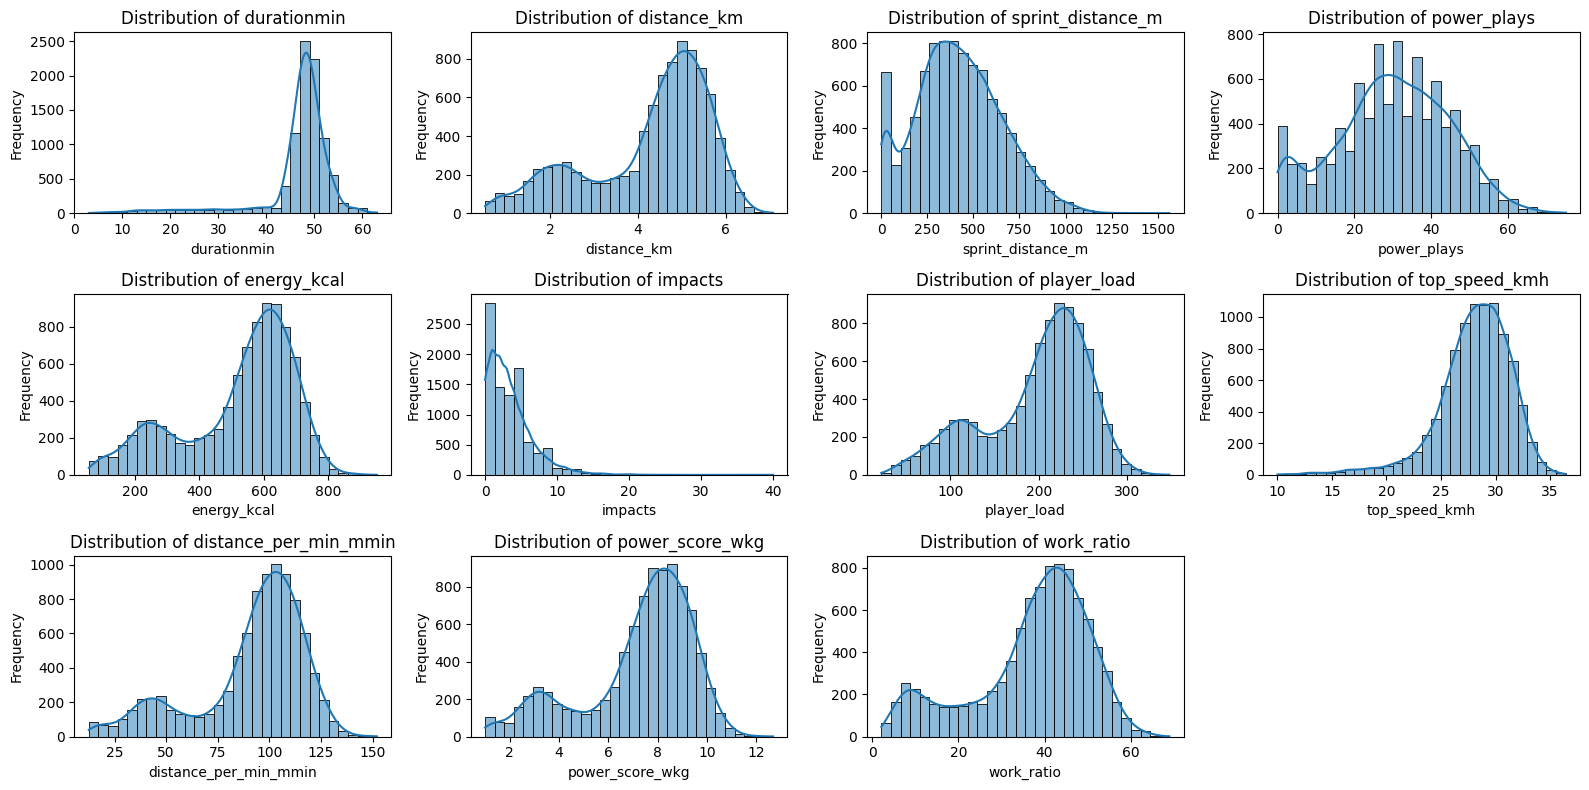

In [347]:
plot_numerical_distributions(df)

In [348]:
describe_categorical_columns(df)

,count,unique,top,freq,%age
split_name,9182,2,2Nd.Half,5094,55.478109
match_day,9182,30,6,366,3.98606
player_club,9182,16,Bul Fc,755,8.222609
against_club,9182,16,Vipers Sc,636,6.926596
location,9182,2,Away,4689,51.067306
result,9182,3,Win,3447,37.540841
player_name,9182,437,Allan Okello,60,0.653452
general_position,9182,4,Defender,3177,34.600305


In [349]:
df[unique_cols].head()

,date,player_name,split_name,match_day,player_club,against_club
0,2025-05-24,Hillary Onek,2Nd.Half,30,Bul Fc,Updf Fc
1,2025-05-24,Benon Tahomera,1St.Half,30,Bul Fc,Updf Fc
2,2025-05-24,Reagan Kalyowa,2Nd.Half,30,Bul Fc,Updf Fc
3,2025-05-24,Karim Ndugwa,2Nd.Half,30,Bul Fc,Updf Fc
4,2025-05-24,Ngobi Pascal,2Nd.Half,30,Bul Fc,Updf Fc


In [350]:
half2_df = df[df['split_name'] == '2Nd.Half']
half2_df = half2_df.drop('split_name', axis=1)

half1_df = df[df['split_name'] == '1St.Half']
half1_df = half1_df.drop('split_name', axis=1)

In [ ]:
merge_keys = ['date', 'player_name', 'player_club', 'against_club', 'match_day','general_position','result','location']

half1_df_rn = half1_df.rename(columns=lambda x: x + '_H1' if x not in merge_keys else x)
half2_df_rn = half2_df.rename(columns=lambda x: x + '_H2' if x not in merge_keys else x)

df_merged = pd.merge(half1_df_rn, half2_df_rn, on=merge_keys, how='outer')


df_combined = df_merged[merge_keys].copy()

# Numerical Variables of high interest - consider sum
for col in num_cols:
    if col not in ['top_speed_kmh', 'distance_per_min_mmin']:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Use .fillna(0) to handle missing halves
        df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)

# Top Speed - consider max
df_combined['top_speed_kmh'] = df_merged[['top_speed_kmh_H1', 'top_speed_kmh_H2']].max(axis=1)

# distance per minute - recalculate from sum
df_combined['distance_per_min_mmin'] = (df_combined['distance_km'] *1000) / df_combined['durationmin']

#all other numerical variables - consider sum
# Columns in numeric_cols that are not in num_cols
for col in numeric_cols.difference(num_cols):
        if col not in merge_keys:
            h1 = f"{col}_H1"
            h2 = f"{col}_H2"
            # Use .fillna(0) to handle missing halves
            df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)


In [355]:
df_combined.shape

(5390, 93)

In [356]:
df_combined.head()

,date,player_name,player_club,against_club,match_day,general_position,result,location,durationmin,distance_km,...,time_in_power_zone:_35__40_wkg_secs,time_in_power_zone:_40__45_wkg_secs,time_in_power_zone:_45__50_wkg_secs,time_in_power_zone:_5__10_wkg_secs,time_in_power_zone:_>_50_wkg_secs,time_in_speed_zone_1_secs,time_in_speed_zone_2_secs,time_in_speed_zone_3_secs,time_in_speed_zone_4_secs,time_in_speed_zone_5_secs
0,2024-09-13,Amisi Bwangani,Ura Fc,Kcca Fc,1,Defender,Loss,Away,62.0,7.2378,...,37.0,22.9,15.5,971.1,40.6,1243.4,1658.3,645.0,200.5,26.2
1,2024-09-13,Ashraf Mugume,Kcca Fc,Ura Fc,1,Midfielder,Win,Home,46.0,2.9069,...,11.2,7.1,6.2,386.8,14.6,1784.9,712.3,262.2,61.8,5.0
2,2024-09-13,Bright Anukani,Kcca Fc,Ura Fc,1,Midfielder,Win,Home,95.0,11.0300,...,36.9,25.2,13.8,1675.0,24.9,1639.5,2919.2,1067.8,195.8,7.4
3,2024-09-13,Bruno Junior Bunyaga,Ura Fc,Kcca Fc,1,Forward,Loss,Away,50.0,5.2463,...,18.6,14.8,10.4,874.9,33.1,957.1,1586.5,358.0,94.0,12.9
4,2024-09-13,Derrick Ochan,Ura Fc,Kcca Fc,1,Goalkeeper,Loss,Away,97.0,4.3116,...,3.9,2.6,2.7,567.9,6.1,4375.5,1425.0,82.5,0.7,0.0


In [357]:
describe_numeric_columns(df_combined)

,count,mean,std,min,median,max
durationmin,5390.0,79.577737,25.691487,3.000000,94.000000,116.000000
distance_km,5390.0,7.282387,3.159754,0.516700,8.316300,13.499000
sprint_distance_m,5390.0,717.201380,425.426218,0.000000,697.355000,2894.443000
power_plays,5390.0,51.067161,27.508273,0.000000,52.000000,145.000000
energy_kcal,5390.0,889.797505,390.680461,60.422800,1012.553650,1769.565600
impacts,5390.0,5.792393,4.738998,0.000000,5.000000,46.000000
player_load,5390.0,335.711662,137.585222,24.251500,371.797350,655.960600
top_speed_kmh,5390.0,28.823073,3.290946,10.208100,29.296200,36.416300
distance_per_min_mmin,5390.0,90.558118,25.603673,12.770213,97.074272,177.933333
power_score_wkg,5390.0,12.369186,5.052780,1.001100,14.043500,21.833900


In [358]:
match_df = df_combined

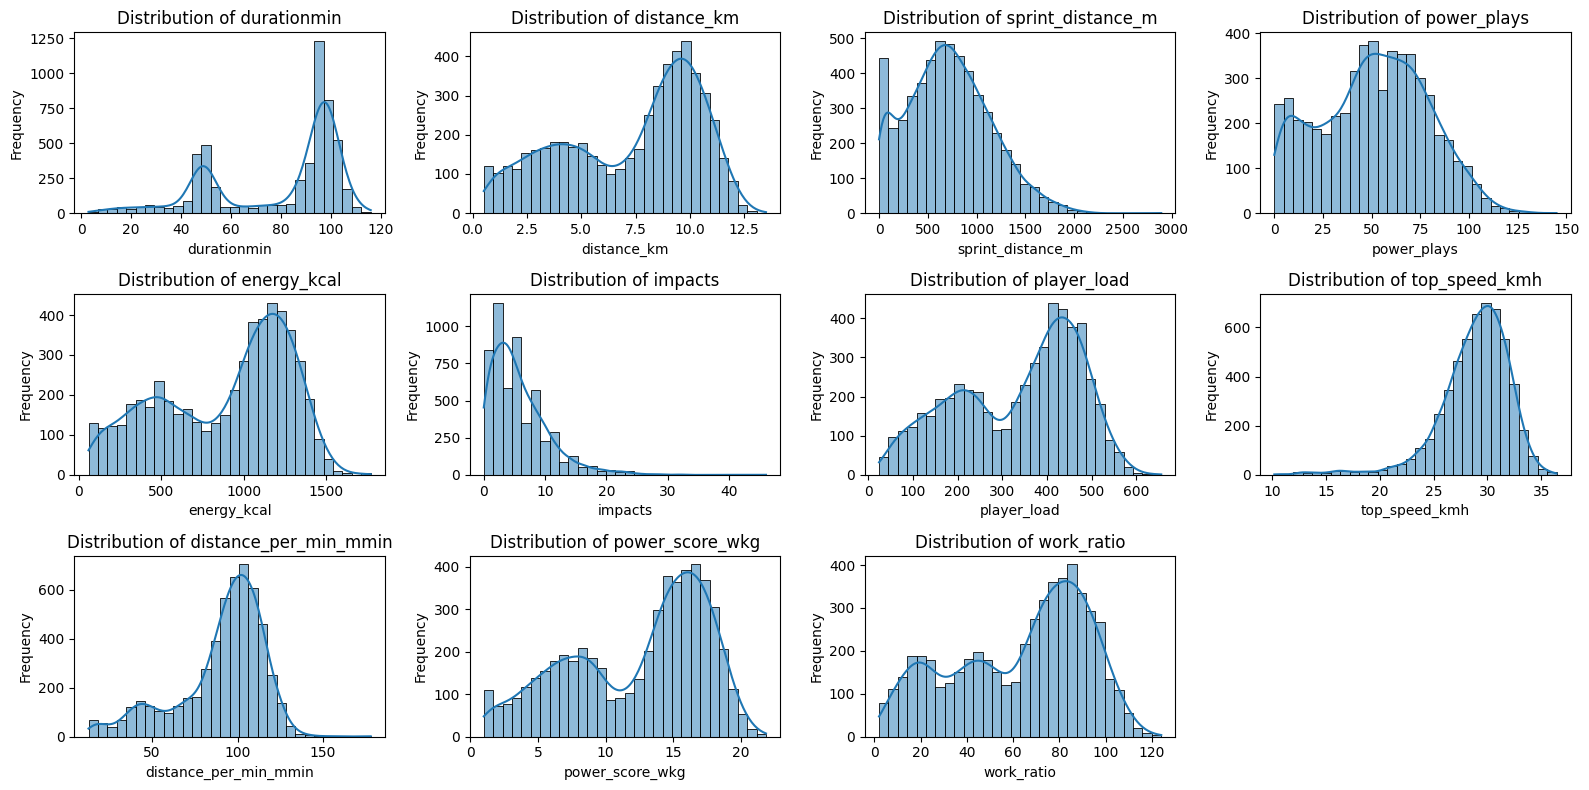

In [359]:
plot_numerical_distributions(match_df)

## Data Quality and Integrity Checks

In [360]:
num_teams = 16
players_min_per_game = 11
players_max_per_game = 16 #including all 5 substitutes
matches = 30

expected_min_entries = num_teams * players_min_per_game * matches
expected_max_entries = num_teams * players_max_per_game * matches
actual_entries = len(match_df)

print(f"Expected minimum entries: {expected_min_entries}")
print(f"Expected maximum entries: {expected_max_entries}")
print(f"Actual entries in match_df: {actual_entries}")

print(f"Percentage of expected entries: {actual_entries / expected_min_entries * 100:.2f}%")
print(f"Percentage of expected entries (max): {actual_entries / expected_max_entries * 100:.2f}%")

Expected minimum entries: 5280
Expected maximum entries: 7680
Actual entries in match_df: 5390
Percentage of expected entries: 102.08%
Percentage of expected entries (max): 70.18%


In [361]:
# Calculate the average number of players per match day for each team
players_per_matchday = (
    match_df.groupby(['player_club', 'match_day'], observed=True)['player_name']
    .nunique()
    .groupby('player_club', observed=True)
    .mean()
    .reset_index(name='avg_players_per_matchday')
)

players_per_matchday.sort_values(by='avg_players_per_matchday',ascending=False)

# Too many players (e.g. >16) = duplicate entries or data error.
# Too few players (<11) = missing data, poor pod usage(few players use pods)

,player_club,avg_players_per_matchday
13,Ura Fc,15.000000
0,Bul Fc,14.833333
12,Updf Fc,14.827586
8,Nec Fc,14.533333
11,Soltilo Bright Stars Fc,14.344828
4,Lugazi Fc,14.206897
5,Maroons Fc,14.125000
7,Mbarara City Fc,13.592593
15,Wakiso Giants Fc,13.440000
2,Kcca Fc,13.346154


In [362]:
total_matchdays_per_player = (
    match_df.groupby(['player_name','player_club'], observed=True)['match_day']
    .nunique()
    .reset_index(name='total_matchdays')
    .sort_values(by='total_matchdays', ascending=False)
)

total_matchdays_per_player



,player_name,player_club,total_matchdays
19,Allan Okello,Vipers Sc,29
46,Atendele Geriga,Nec Fc,28
152,Freedom Mungudit,Lugazi Fc,28
244,Joseph Ssemujju,Ura Fc,28
247,Joshua Letti Lubwama,Ura Fc,27
...,...,...,...
425,Ssenjogera Conrad,Express Fc,1
431,Sulaiman Kibalama,Updf Fc,1
430,Steven Munguchi,Kcca Fc,1
38,Arnold Odong,Bul Fc,1


In [363]:
# Step 1: count distinct match days per player per team
player_matchdays = (
    match_df
    .groupby(['player_club','player_name'], observed=True)['match_day']
    .nunique()
    .reset_index(name='matchdays')
)
# Step 2: calculate team stats based on player matchdays

team_stats = (
    player_matchdays
    .groupby('player_club', observed=True)['matchdays']
    .agg(
        avg_matchdays_per_player = 'mean',
        total_matchdays_per_player = 'max',
        min_matchdays_per_player = 'min',
        median_matchdays_per_player = 'median',
        squad_size = 'count'
    )
    .reset_index()
    .sort_values(by='avg_matchdays_per_player', ascending=False)
)

team_stats

,player_club,avg_matchdays_per_player,total_matchdays_per_player,min_matchdays_per_player,median_matchdays_per_player,squad_size
11,Soltilo Bright Stars Fc,16.000000,26,2,17.0,26
8,Nec Fc,15.571429,28,1,16.0,28
12,Updf Fc,14.827586,26,1,18.0,29
13,Ura Fc,14.500000,28,1,12.5,30
4,Lugazi Fc,14.206897,28,1,14.0,29
3,Kitara Fc,12.833333,26,1,11.0,30
7,Mbarara City Fc,12.655172,26,1,11.0,29
5,Maroons Fc,12.107143,22,1,12.0,28
14,Vipers Sc,12.107143,29,1,11.0,28
2,Kcca Fc,11.965517,25,1,13.0,29


In [364]:
zero_frac = (match_df == 0).mean().sort_values(ascending=False)
sparse = zero_frac[zero_frac > 0.95]
sparse.index.tolist()

#drop these columns from the match dataset
match_df = match_df.drop(columns=sparse.index.tolist())


In [365]:
# e.g. no negative distances, reasonable top speeds
assert (match_df['distance_km'] >= 0).all()
assert match_df['top_speed_kmh'].between(0, 40).all()


In [366]:
describe_categorical_columns(match_df)

,count,unique,top,freq,%age
player_name,5390,437,Allan Okello,30,0.556586
player_club,5390,16,Bul Fc,445,8.25603
against_club,5390,16,Vipers Sc,375,6.957328
match_day,5390,30,8,216,4.007421
general_position,5390,4,Midfielder,1783,33.079777
result,5390,3,Win,2009,37.272727
location,5390,2,Away,2749,51.001855


### Export cleaned datasets

In [367]:
df.to_csv('UPL25_all_halves.csv',index=False)
half1_df.to_csv('UPL25_first_half.csv',index=False)
half2_df.to_csv('UPL25_second_half.csv',index=False)
match_df.to_csv('UPL25_matches.csv',index=False)